# Neural Machine Translation with Attention Mechanism — **SOLUTION KEY**

**Course**: CSC 383/483: Applied Deep Learning  


## Setup

In [30]:
import numpy as np
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import unicodedata
import random

print("Keras version:", keras.__version__)

Keras version: 3.10.0


## Dataset

In [31]:
import pandas as pd
df = pd.read_csv("/content/english_french.csv", on_bad_lines='skip', engine='python').dropna()
print(df.shape)
print(df.head())

(80100, 2)
  English    French
0     Go.      Va !
1     Hi.   Salut !
2     Hi.    Salut.
3    Run.   Fuyez !
4    Run.  Fuyons !


---
## Task 1: Prepare the Data — SOLUTION [15/100]

In [32]:
# ── 1.1 Text Cleaning ─────────────────────────────────────────────────────────
def clean_sentence(sentence):
    sentence = unicodedata.normalize('NFD', sentence)
    sentence = sentence.lower()
    sentence = re.sub(r"([.!?,'])", r" \1", sentence)
    sentence = sentence.strip()
    sentence = re.sub(r' +', ' ', sentence)
    return sentence


In [33]:
# ── 1.2 Build Parallel Corpus ─────────────────────────────────────────────────
MAX_SAMPLES = 40000

df_sample = df.sample(n=min(MAX_SAMPLES, len(df)), random_state=42).reset_index(drop=True)

mask = df_sample['English'].apply(isinstance, args=(str,)) & df_sample['French'].apply(isinstance, args=(str,))
df_clean = df_sample[mask].copy()

eng_sentences = df_clean['English'].apply(clean_sentence).tolist()
fra_sentences = ('<start> ' + df_clean['French'].apply(clean_sentence) + ' <end>').tolist()

random_indices = random.sample(range(len(eng_sentences)), 5)
for i in random_indices:
    print(f"EN: {eng_sentences[i]}")
    print(f"FR: {fra_sentences[i]}")
    print("")


EN: is that for me ?
FR: <start> est-ce pour moi ? <end>

EN: tom was irrational .
FR: <start> tom était irrationnel . <end>

EN: that 's what i 'd want .
FR: <start> c 'est ce que je voudrais . <end>

EN: drink some coffee .
FR: <start> buvez du café . <end>

EN: the joke 's on you .
FR: <start> on se moque de vous . <end>



In [34]:
# ── 1.3 Tokenization ──────────────────────────────────────────────────────────
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

eng_tokenizer = Tokenizer(filters='')
fra_tokenizer = Tokenizer(filters='')

eng_tokenizer.fit_on_texts(eng_sentences)
fra_tokenizer.fit_on_texts(fra_sentences)

eng_sequences = eng_tokenizer.texts_to_sequences(eng_sentences)
fra_sequences = fra_tokenizer.texts_to_sequences(fra_sentences)

eng_vocab_size = len(eng_tokenizer.word_index) + 1
fra_vocab_size = len(fra_tokenizer.word_index) + 1
max_eng_len    = max(len(s) for s in eng_sequences)
max_fra_len    = max(len(s) for s in fra_sequences)

print("English vocab size:", eng_vocab_size)
print("French  vocab size:", fra_vocab_size)
print("Max English length:", max_eng_len)
print("Max French  length:", max_fra_len)

English vocab size: 6179
French  vocab size: 12922
Max English length: 10
Max French  length: 16


In [35]:
# ── 1.4 Pad & Split ───────────────────────────────────────────────────────────
np.random.seed(42)

eng_padded = pad_sequences(eng_sequences, maxlen=max_eng_len, padding='post')
fra_padded = pad_sequences(fra_sequences, maxlen=max_fra_len, padding='post')

decoder_input  = fra_padded[:, :-1]  # <start> ... (all but last)
decoder_target = fra_padded[:, 1:]   # ... <end>   (all but first)

indices = np.arange(len(eng_padded))
np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, test_idx = indices[:split], indices[split:]

encoder_input_train  = eng_padded[train_idx]
decoder_input_train  = decoder_input[train_idx]
decoder_target_train = decoder_target[train_idx]
encoder_input_test   = eng_padded[test_idx]
decoder_input_test   = decoder_input[test_idx]
decoder_target_test  = decoder_target[test_idx]
test_sentences = [eng_sentences[i] for i in test_idx[:10]]

print("encoder_input_train shape: ", encoder_input_train.shape)
print("decoder_input_train shape: ", decoder_input_train.shape)
print("decoder_target_train shape:", decoder_target_train.shape)

encoder_input_train shape:  (32000, 10)
decoder_input_train shape:  (32000, 15)
decoder_target_train shape: (32000, 15)


---
## Task 2: Visualize the Data — SOLUTION [5/100]

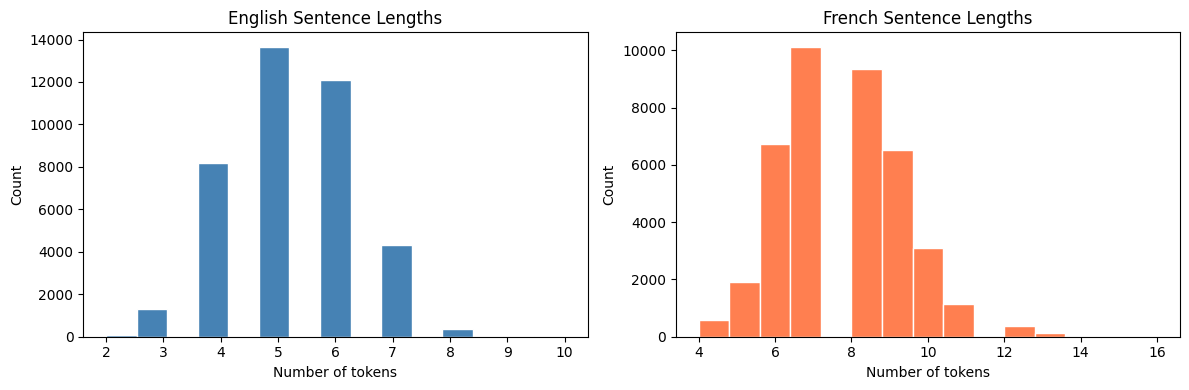


5 random training pairs:
  EN: he became a pianist .
  FR: <start> il devint pianiste . <end>

  EN: did you do all this ?
  FR: <start> avez-vous fait tout ceci ? <end>

  EN: can i extend my stay ?
  FR: <start> puis-je prolonger mon séjour  ? <end>

  EN: you are a good student .
  FR: <start> tu es une bonne étudiante . <end>

  EN: go easy on the wine .
  FR: <start> vas-y doucement avec le vin . <end>



In [36]:
eng_lengths = [len(s) for s in eng_sequences]
fra_lengths = [len(s) for s in fra_sequences]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eng_lengths, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('English Sentence Lengths')
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Count')

axes[1].hist(fra_lengths, bins=15, color='coral', edgecolor='white')
axes[1].set_title('French Sentence Lengths')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print 5 random training examples
print("\n5 random training pairs:")
sample_idx = np.random.choice(len(train_idx), 5, replace=False)
for idx in sample_idx:
    real_idx = train_idx[idx]
    eng_text = eng_tokenizer.sequences_to_texts([eng_sequences[real_idx]])[0]
    fra_text = fra_tokenizer.sequences_to_texts([fra_sequences[real_idx]])[0]
    print(f"  EN: {eng_text}")
    print(f"  FR: {fra_text}")
    print()

---
## Task 3: Build the Encoder — SOLUTION [15/100]

In [37]:
EMBED_DIM = 64
UNITS     = 128

def build_encoder(vocab_size, embed_dim, units, max_len):
    encoder_inputs = keras.Input(shape=(max_len,), dtype='int32', name='encoder_inputs')
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True, name='encoder_embedding')(encoder_inputs)
    encoder_outputs, state_h, state_c = layers.LSTM(
        units, return_sequences=True, return_state=True, name='encoder_lstm'
    )(x)
    model = keras.Model(
        inputs=encoder_inputs,
        outputs=[encoder_outputs, state_h, state_c],
        name='encoder'
    )
    return model

encoder_model = build_encoder(eng_vocab_size, EMBED_DIM, UNITS, max_eng_len)
encoder_model.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 10, 64)    │    395,456 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 10)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 10, 128), │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_2[0][0] │
│                     │ (None, 128)]      │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 494,272 (1.89 MB)

 Trainable params: 494,272 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Build the Attention Layer — SOLUTION [20/100]

In [38]:
class BahdanauAttention(keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units, use_bias=False)
        self.W2 = layers.Dense(units, use_bias=False)
        self.V  = layers.Dense(1, use_bias=False)

    def call(self, encoder_outputs, decoder_hidden):
        # decoder_hidden: (batch, units) → (batch, 1, units)
        decoder_hidden_exp = tf.expand_dims(decoder_hidden, 1)
        # score: (batch, src_len, 1)
        score = self.V(tf.nn.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden_exp)))
        # attention_weights: (batch, src_len, 1)
        attention_weights = tf.nn.softmax(score, axis=1)
        # context_vector: (batch, units)
        context_vector = tf.reduce_sum(attention_weights * encoder_outputs, axis=1)
        return context_vector, attention_weights

# Sanity check
attn_layer = BahdanauAttention(UNITS)
dummy_enc  = tf.random.normal((2, max_eng_len, UNITS))
dummy_hid  = tf.random.normal((2, UNITS))
ctx, wts   = attn_layer(dummy_enc, dummy_hid)
print("Context vector shape:   ", ctx.shape)   # (2, 256)
print("Attention weights shape:", wts.shape)   # (2, max_eng_len, 1)

Context vector shape:    (2, 128)
Attention weights shape: (2, 10, 1)


---
## Task 5: Build the Decoder — SOLUTION [20/100]

In [39]:
class DecoderStep(keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, units, **kwargs):
        super().__init__(**kwargs)
        self.embedding  = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.attention  = BahdanauAttention(units)
        self.lstm_cell  = layers.LSTMCell(units)
        self.dense      = layers.Dense(vocab_size, activation='softmax')

    def call(self, decoder_input_token, decoder_states, encoder_outputs):
        # decoder_input_token: (batch,)  integer token ids
        h, c = decoder_states

        # Attention context using current h
        context_vector, attention_weights = self.attention(encoder_outputs, h)

        # Embed the input token: (batch,) → (batch, embed_dim)
        x = self.embedding(decoder_input_token)  # (batch, embed_dim)

        # Concatenate embedding and context: (batch, embed_dim + units)
        lstm_input = tf.concat([x, context_vector], axis=-1)  # (batch, embed_dim+units)

        # LSTM cell step
        output, [new_h, new_c] = self.lstm_cell(lstm_input, states=[h, c])

        # Predict next token
        output_logits = self.dense(output)  # (batch, vocab_size)

        return output_logits, [new_h, new_c], attention_weights


def build_training_decoder(decoder_step, encoder_outputs, decoder_input_seq, initial_states, seq_len):
    states = initial_states  # [h, c]
    all_logits = []

    for t in range(seq_len):
        token = decoder_input_seq[:, t]  # (batch,)
        logits, states, _ = decoder_step(token, states, encoder_outputs)
        all_logits.append(logits)  # each: (batch, fra_vocab_size)

    # Stack: (batch, seq_len, fra_vocab_size)
    all_logits = tf.stack(all_logits, axis=1)
    return all_logits

---
## Task 6: Train the Model — SOLUTION [10/100]

USE T4 GPU if You are using Colab

In [40]:
EPOCHS     = 60
BATCH_SIZE = 256

decoder_step = DecoderStep(fra_vocab_size, EMBED_DIM, UNITS)
optimizer    = keras.optimizers.Adam(learning_rate=1e-3)

train_dataset = tf.data.Dataset.from_tensor_slices((
    encoder_input_train.astype(np.int32),
    decoder_input_train.astype(np.int32),
    decoder_target_train.astype(np.int32)
)).shuffle(500).batch(BATCH_SIZE)

loss_fn = keras.losses.SparseCategoricalCrossentropy(reduction='none')

@tf.function
def train_step(enc_input, dec_input, dec_target):
    with tf.GradientTape() as tape:
        enc_out, state_h, state_c = encoder_model(enc_input, training=True)
        seq_len   = dec_input.shape[1]
        all_logits = build_training_decoder(
            decoder_step, enc_out, dec_input, [state_h, state_c], seq_len
        )
        # all_logits: (batch, seq_len, fra_vocab_size)
        # dec_target: (batch, seq_len) integer labels
        raw_loss = loss_fn(dec_target, all_logits)  # (batch, seq_len)

        # Mask padding tokens (id == 0)
        mask = tf.cast(dec_target != 0, tf.float32)  # (batch, seq_len)
        masked_loss = raw_loss * mask
        loss = tf.reduce_sum(masked_loss) / tf.reduce_sum(mask)

    # Collect all trainable variables
    all_vars = encoder_model.trainable_variables + decoder_step.trainable_variables
    grads = tape.gradient(loss, all_vars)
    optimizer.apply_gradients(zip(grads, all_vars))
    return loss


# Training loop
epoch_losses = []
for epoch in range(1, EPOCHS + 1):
    batch_losses = []
    for enc_in, dec_in, dec_tgt in train_dataset:
        batch_loss = train_step(enc_in, dec_in, dec_tgt)
        batch_losses.append(float(batch_loss))
    epoch_loss = np.mean(batch_losses)
    epoch_losses.append(epoch_loss)
    if epoch % 10 == 0:
        print(
              f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Loss: {epoch_loss:.4f} | "
              f"Min: {min(batch_losses):.4f} | "
              f"Max: {max(batch_losses):.4f} | "
              f"Batches: {len(batch_losses)} | "
              f"LR: {optimizer.learning_rate.numpy():.6f}"
          )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention_5' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch  10/60 | Loss: 3.0133 | Min: 2.8497 | Max: 3.1540 | Batches: 125 | LR: 0.001000
Epoch  20/60 | Loss: 2.1644 | Min: 2.0647 | Max: 2.2739 | Batches: 125 | LR: 0.001000
Epoch  30/60 | Loss: 1.6280 | Min: 1.5496 | Max: 1.7539 | Batches: 125 | LR: 0.001000
Epoch  40/60 | Loss: 1.2196 | Min: 1.1337 | Max: 1.3202 | Batches: 125 | LR: 0.001000
Epoch  50/60 | Loss: 0.9258 | Min: 0.8555 | Max: 1.0070 | Batches: 125 | LR: 0.001000
Epoch  60/60 | Loss: 0.7187 | Min: 0.6474 | Max: 0.8070 | Batches: 125 | LR: 0.001000


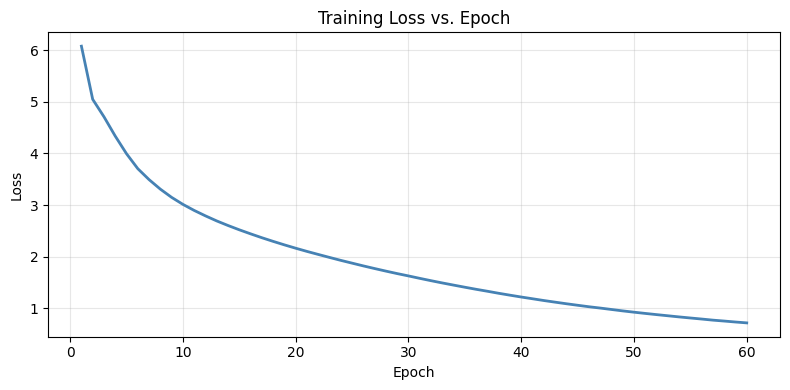

In [41]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), epoch_losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epoch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task 7: Inference & Translation — SOLUTION [10/100]

In [42]:
fra_index_to_word = {v: k for k, v in fra_tokenizer.word_index.items()}
start_token_id = fra_tokenizer.word_index['<start>']
end_token_id   = fra_tokenizer.word_index['<end>']

def translate(sentence):
    # Clean and tokenize
    cleaned = clean_sentence(sentence)
    seq     = eng_tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_eng_len, padding='post')  # (1, max_eng_len)

    # Encode
    enc_out, h, c = encoder_model(padded.astype(np.int32), training=False)
    states = [h, c]

    # Greedy decode
    current_token = tf.constant([[start_token_id]], dtype=tf.int32)  # (1, 1)
    result_tokens = []
    attention_matrices = []

    for _ in range(max_fra_len):
        token_1d = tf.squeeze(current_token, axis=1)  # (1,)
        logits, states, attn_weights = decoder_step(token_1d, states, enc_out)
        # logits: (1, fra_vocab_size)
        predicted_id = int(tf.argmax(logits, axis=-1).numpy()[0])
        attention_matrices.append(attn_weights.numpy()[0, :, 0])  # (src_len,)

        if predicted_id == end_token_id:
            break

        result_tokens.append(fra_index_to_word.get(predicted_id, ''))
        current_token = tf.constant([[predicted_id]], dtype=tf.int32)

    translation      = ' '.join(result_tokens)
    attention_matrix = np.array(attention_matrices)  # (output_len, src_len)
    return translation, attention_matrix


random_samples = df.sample(n=5)

for _, row in random_samples.iterrows():
    sentence    = row["English"]
    actual_french = row["French"]
    translation, _ = translate(sentence)
    print(f"EN:            {sentence}")
    print(f"FR (model):    {translation}")
    print(f"FR (actual):   {actual_french}")
    print()

EN:            How much did this cost?
FR (model):    combien cela coûte-t-il  ?
FR (actual):   Combien ça a coûté ?

EN:            I have a date.
FR (model):    j 'ai un gros .
FR (actual):   J'ai un rendez-vous galant.

EN:            He came back from China.
FR (model):    il est venu à l 'aide .
FR (actual):   Il est revenu de Chine.

EN:            I got up about six.
FR (model):    je me suis levée vers six heures .
FR (actual):   Je me suis réveillé vers six heures.

EN:            No one will know.
FR (model):    personne ne saura .
FR (actual):   Personne ne le saura.



---
## Task 8: Visualize Attention Weights — SOLUTION [5/100]

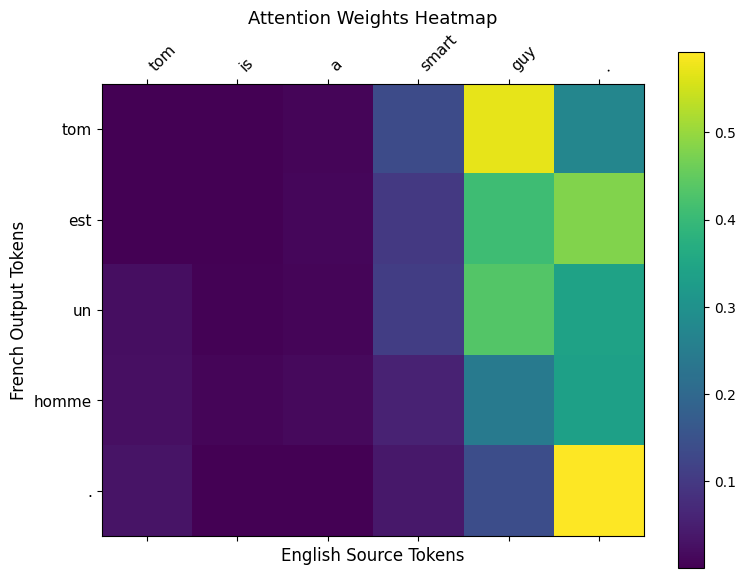

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention_5' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


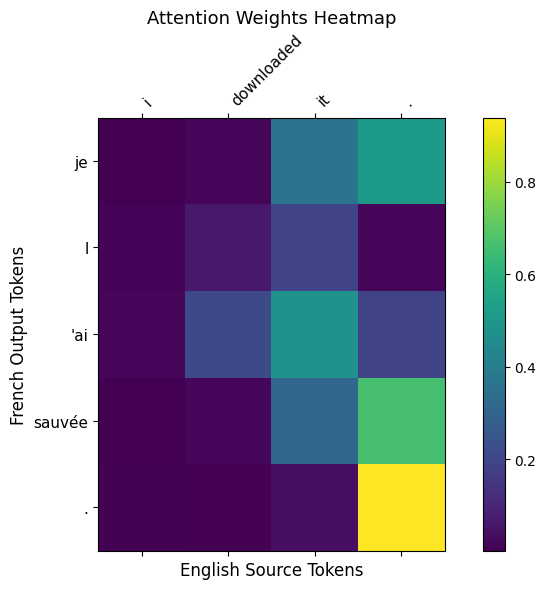

In [43]:
def plot_attention(src_tokens, tgt_tokens, attention_matrix):
    """
    Plot attention heatmap.
    attention_matrix shape: (output_len, src_len)
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.matshow(attention_matrix, cmap='viridis')
    fig.colorbar(cax)

    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='left', fontsize=11)
    ax.set_yticklabels(tgt_tokens, fontsize=11)

    ax.set_xlabel('English Source Tokens', fontsize=12)
    ax.set_ylabel('French Output Tokens', fontsize=12)
    ax.set_title('Attention Weights Heatmap', fontsize=13)

    plt.tight_layout()
    plt.show()


# Visualize attention for 2 test sentences
for sent in test_sentences[:2]:
    translation, attn = translate(sent)
    src_tokens = clean_sentence(sent).split()
    tgt_tokens = translation.split()

    # Trim attention matrix to match actual output length and source length
    attn_trimmed = attn[:len(tgt_tokens), :len(src_tokens)]
    plot_attention(src_tokens, tgt_tokens, attn_trimmed)

---
## Grading Notes

**General guidance:**
- Award partial credit if the structure is correct but shapes are slightly off due to minor bugs.
- Attention heatmaps don't need to be perfect — as long as the implementation is correct and the visualization is labeled, award full marks.
- If training loss is not decreasing at all, deduct 5 points from Task 6 and investigate whether the mask or the loss function is incorrect.
- PyTorch usage = automatic zero per course policy.

**Common student mistakes:**
1. Forgetting `return_sequences=True` in the encoder LSTM — attention cannot be computed without all hidden states.
2. Using `axis=0` instead of `axis=1` in softmax — gives wrong attention distribution.
3. Not masking padding tokens in the loss — inflated accuracy, deflated loss.
4. Not concatenating the context vector with the token embedding before the LSTM cell.
5. Using `model.fit()` instead of a custom training loop — fine if it works, but teacher forcing must be explicit.

*End of Key*